In [1]:
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from src.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from src.model.pc_4 import HierarchicalPCCNN

In [2]:
SEED = 42
BATCH_SIZE = 16

NUM_CLASSES = 2
IMAGES_PER_CLASS = 10

INFERENCE_STEPS = None

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: mps


In [4]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(
    TinyImageNetLoader(seed=SEED),
    image_size=64
).load()

train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]

In [5]:
selected_classes = list(range(NUM_CLASSES))

class_indices = defaultdict(list)

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)

    if label in selected_classes:
        class_indices[label].append(i)


generator = torch.Generator()
generator.manual_seed(SEED)

indices = []

for class_id in selected_classes:
    available_indices = class_indices[class_id]

    if len(available_indices) < IMAGES_PER_CLASS:
        raise ValueError(f"Class {class_id} has only {len(available_indices)} images, but {IMAGES_PER_CLASS} were requested.")

    perm = torch.randperm(len(available_indices), generator=generator)[:IMAGES_PER_CLASS]
    selected = [available_indices[i] for i in perm.tolist()]
    indices.extend(selected)


train_subset = Subset(train_dataset, indices)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

print("Total Tiny ImageNet training images:", len(train_dataset))
print("Selected classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))
print("Images per class:", IMAGES_PER_CLASS)
print("Training images:", len(train_subset))
print("Training batches:", len(train_loader))

Total Tiny ImageNet training images: 99953
Selected classes: [0, 1]
Number of selected classes: 2
Images per class: 10
Training images: 20
Training batches: 2


In [6]:
model = HierarchicalPCCNN(inference_steps=INFERENCE_STEPS).to(device)

print(model)

HierarchicalPCCNN(
  (level1): ModuleDict(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (level2): ModuleDict(
    (conv): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
)


In [7]:
image, label = train_subset[0]

r1, r2, steps, converged = model.infer(image)

print("Input:", image.shape)
print("r1:", r1.shape)
print("r2:", r2.shape)
print("steps:", steps)
print("converged:", converged)

Input: torch.Size([3, 64, 64])
r1: torch.Size([1, 32, 32, 32])
r2: torch.Size([1, 128, 16, 16])
steps: 17589
converged: True


In [8]:
epochs = 2
history = []

for epoch in range(epochs):
    total_error_0 = 0.0
    total_error_1 = 0.0
    total_images = 0

    total_inference_steps = 0
    min_inference_steps = None
    max_inference_steps = 0

    W1_before = model.level1["conv"].weight.clone()
    W2_before = model.level2["conv"].weight.clone()

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):

        for image in images:
            result = model(image)

            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]

            steps = result["inference_steps"]

            total_inference_steps += steps
            max_inference_steps = max(max_inference_steps, steps)

            if min_inference_steps is None:
                min_inference_steps = steps
            else:
                min_inference_steps = min(min_inference_steps, steps)

            total_images += 1

    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images
    mean_inference_steps = total_inference_steps / total_images

    W1_change = (model.level1["conv"].weight - W1_before).abs().mean().item()
    W2_change = (model.level2["conv"].weight - W2_before).abs().mean().item()

    history.append({
        "epoch": epoch + 1,
        "error_0": mean_error_0,
        "error_1": mean_error_1,
        "mean_inference_steps": mean_inference_steps,
        "min_inference_steps": min_inference_steps,
        "max_inference_steps": max_inference_steps,
        "W1_change": W1_change,
        "W2_change": W2_change
    })

    print(f"\nEpoch {epoch + 1}")
    print(f"Mean image error:       {mean_error_0:.6f}")
    print(f"Mean r1 error:          {mean_error_1:.6f}")
    print(f"Mean inference steps:   {mean_inference_steps:.2f}")
    print(f"Minimum inference steps:{min_inference_steps}")
    print(f"Maximum inference steps:{max_inference_steps}")
    print(f"W1 mean change:         {W1_change:.8f}")
    print(f"W2 mean change:         {W2_change:.8f}")

Epoch 1/2:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch 1
Mean image error:       0.127122
Mean r1 error:          0.065864
Mean inference steps:   15841.10
Minimum inference steps:14645
Maximum inference steps:18092
W1 mean change:         0.00542972
W2 mean change:         0.00453878


Epoch 2/2:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch 2
Mean image error:       0.067498
Mean r1 error:          0.039364
Mean inference steps:   15290.55
Minimum inference steps:14389
Maximum inference steps:16372
W1 mean change:         0.00128389
W2 mean change:         0.00106453


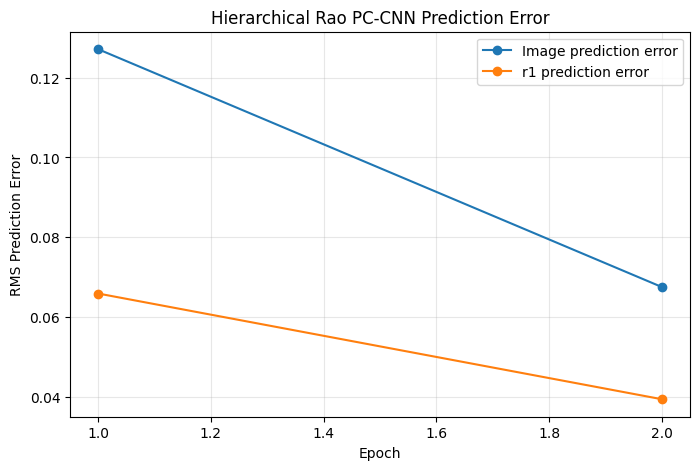

In [9]:
epochs_plot = [item["epoch"] for item in history]
error_0_plot = [item["error_0"] for item in history]
error_1_plot = [item["error_1"] for item in history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, error_0_plot, marker="o", label="Image prediction error")
plt.plot(epochs_plot, error_1_plot, marker="o", label="r1 prediction error")

plt.xlabel("Epoch")
plt.ylabel("RMS Prediction Error")
plt.title("Hierarchical Rao PC-CNN Prediction Error")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [10]:
# MEAN = torch.tensor(train_dataset.mean, dtype=torch.float32).view(3, 1, 1)
# STD = torch.tensor(train_dataset.std, dtype=torch.float32).view(3, 1, 1)
#
# print(MEAN)
# print(STD)


def to_display_image(image):
    image = image.detach().cpu()
    # image = image * STD + MEAN
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()

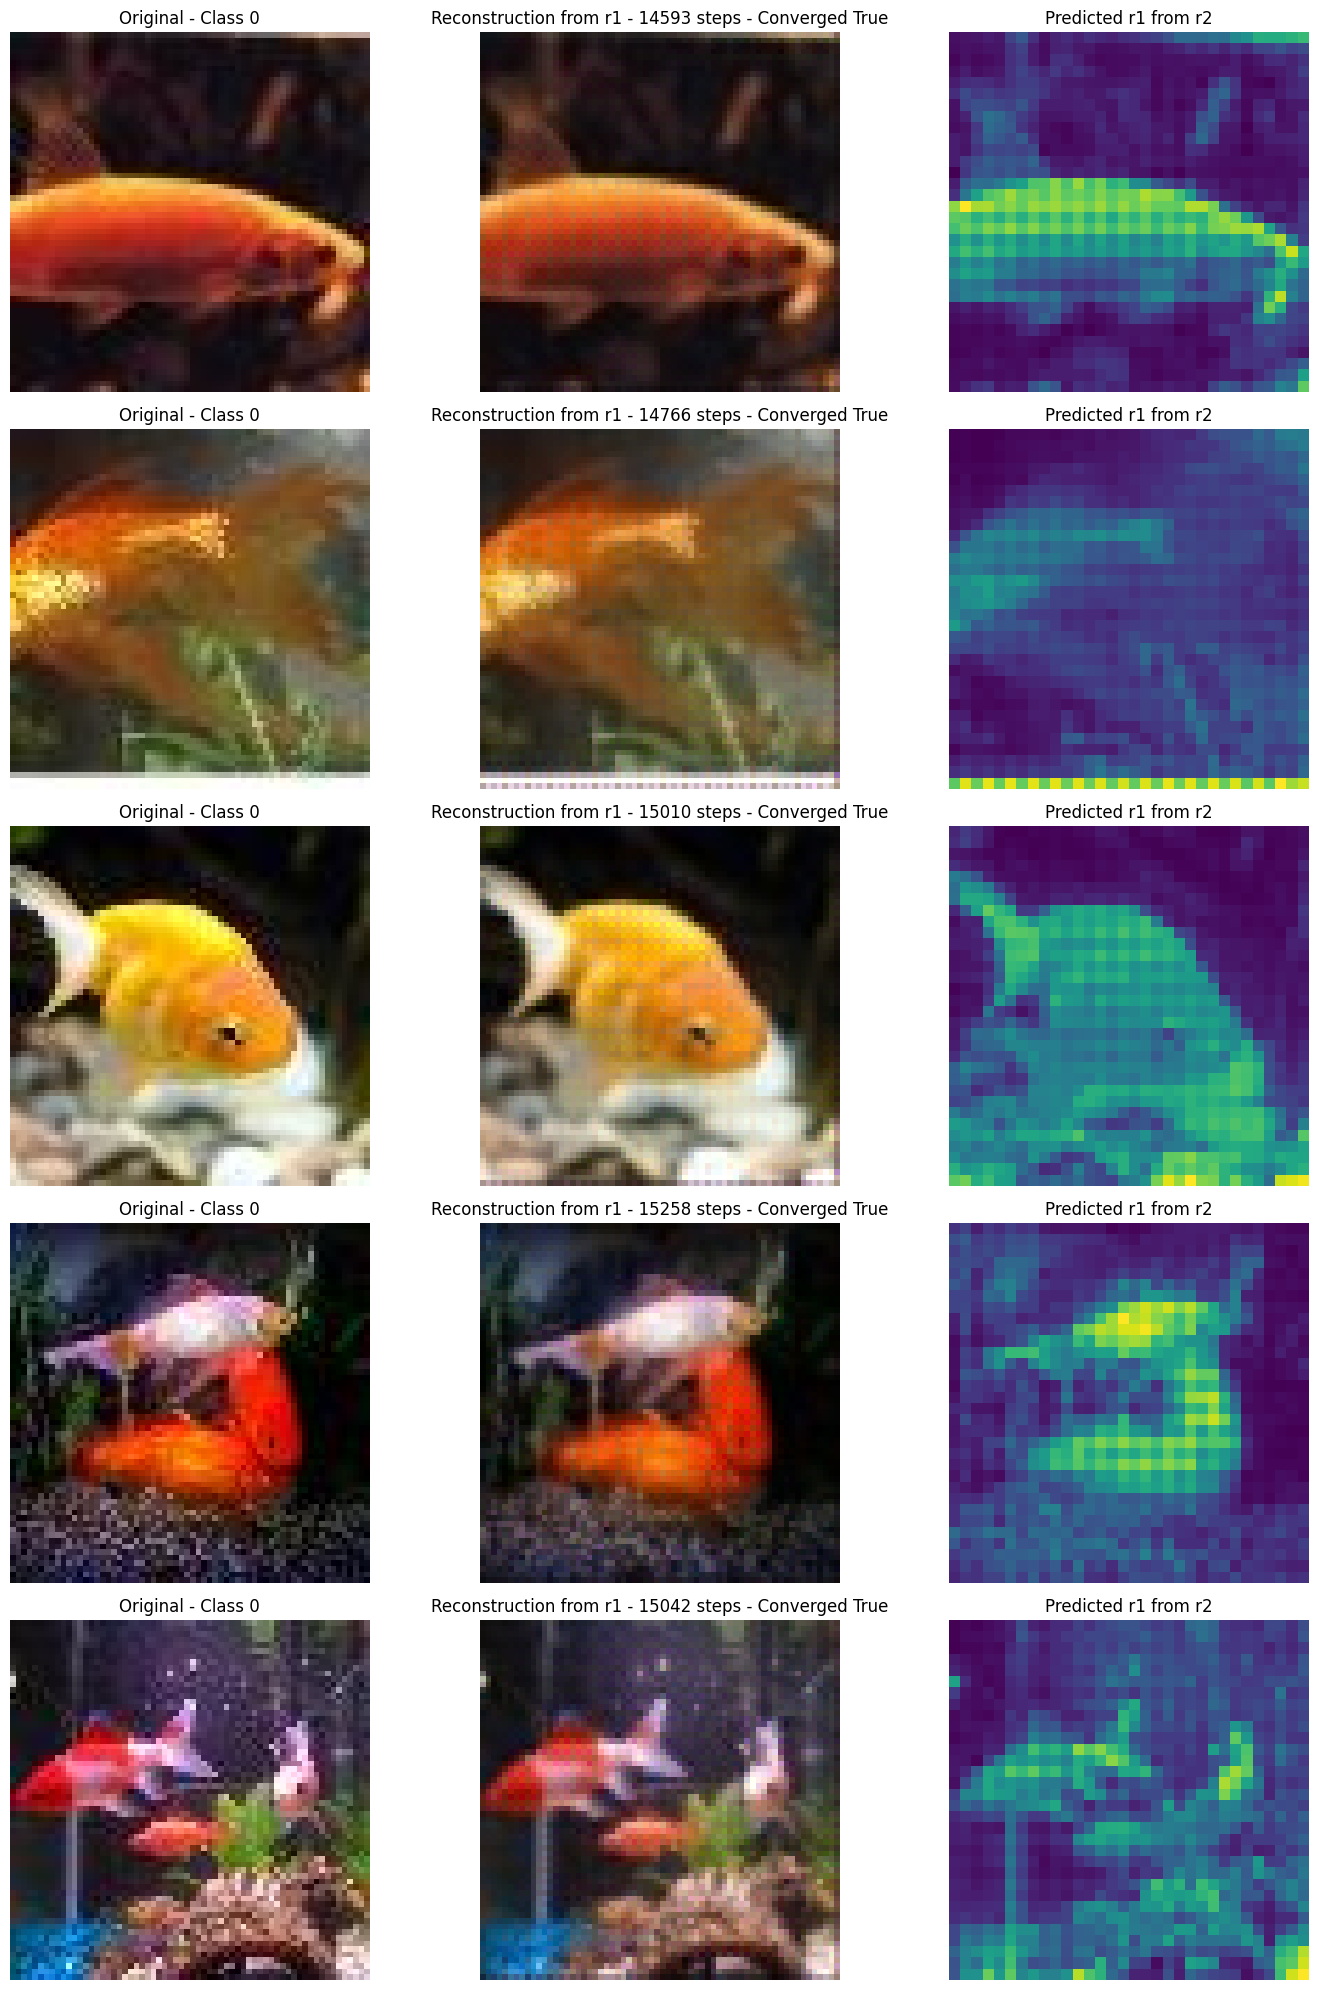

In [11]:
num_images = 5

fig, axes = plt.subplots(num_images, 3, figsize=(15, num_images * 4))

last_predicted_r1 = None
last_r2 = None
last_label = None

for i in range(num_images):
    image, label = train_subset[i]

    reconstruction, predicted_r1, reconstruction_r2, r2, steps, converged = model.reconstruct(image)

    axes[i, 0].imshow(to_display_image(image))
    axes[i, 0].set_title(f"Original - Class {label}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(to_display_image(reconstruction))
    axes[i, 1].set_title(f"Reconstruction from r1 - {steps} steps - Converged {converged}")
    axes[i, 1].axis("off")

    predicted_r1_map = predicted_r1.abs().mean(dim=0).detach().cpu()

    axes[i, 2].imshow(predicted_r1_map)
    axes[i, 2].set_title("Predicted r1 from r2")
    axes[i, 2].axis("off")

    last_predicted_r1 = predicted_r1
    last_r2 = r2
    last_label = label

plt.tight_layout()
plt.show()

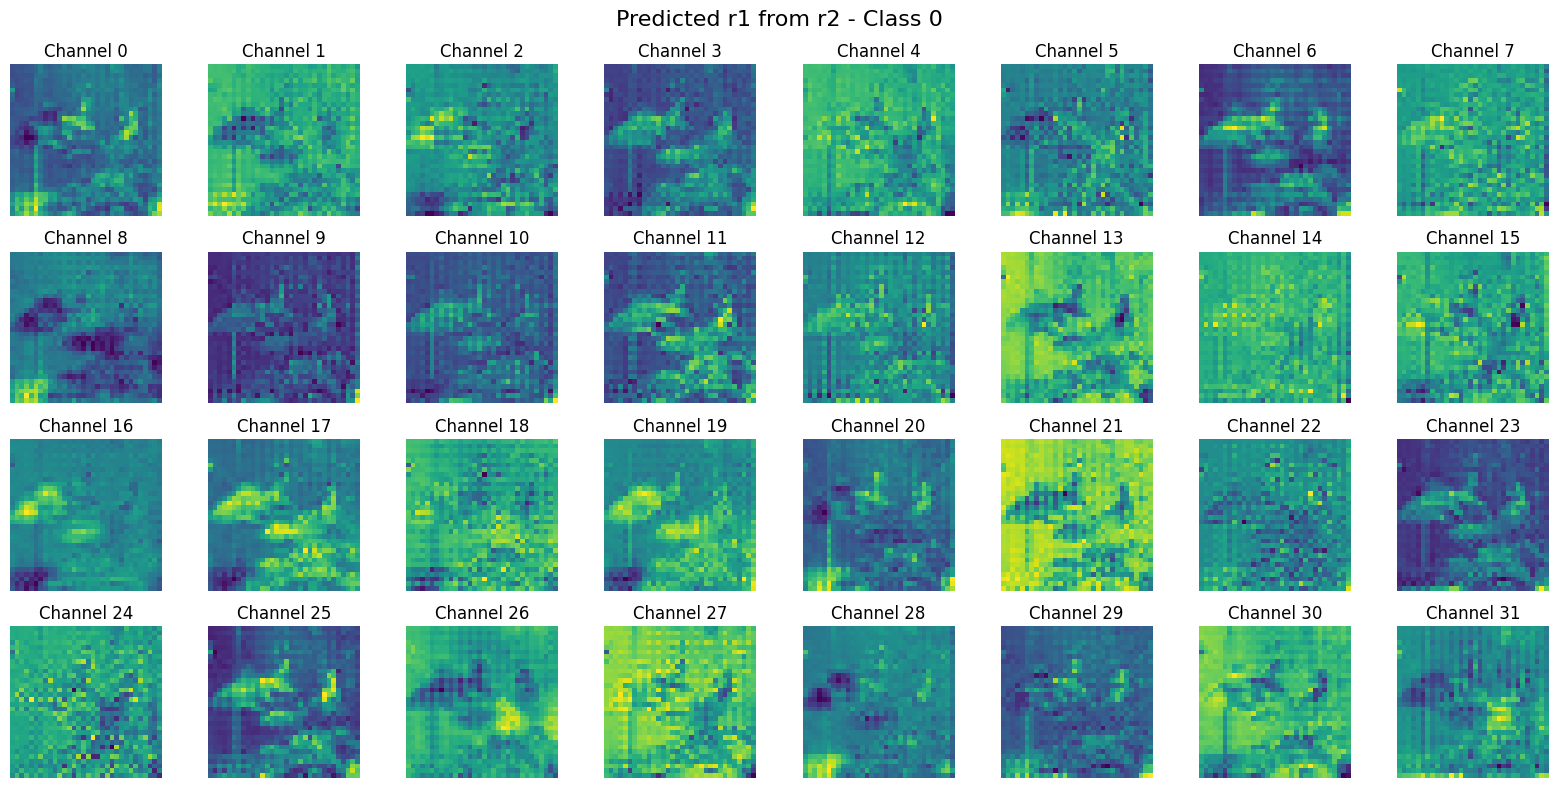

In [12]:
feature = last_predicted_r1.detach().cpu()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for j, ax in enumerate(axes.flat):
    ax.imshow(feature[j])
    ax.set_title(f"Channel {j}")
    ax.axis("off")

fig.suptitle(f"Predicted r1 from r2 - Class {last_label}", fontsize=16)

plt.tight_layout()
plt.show()

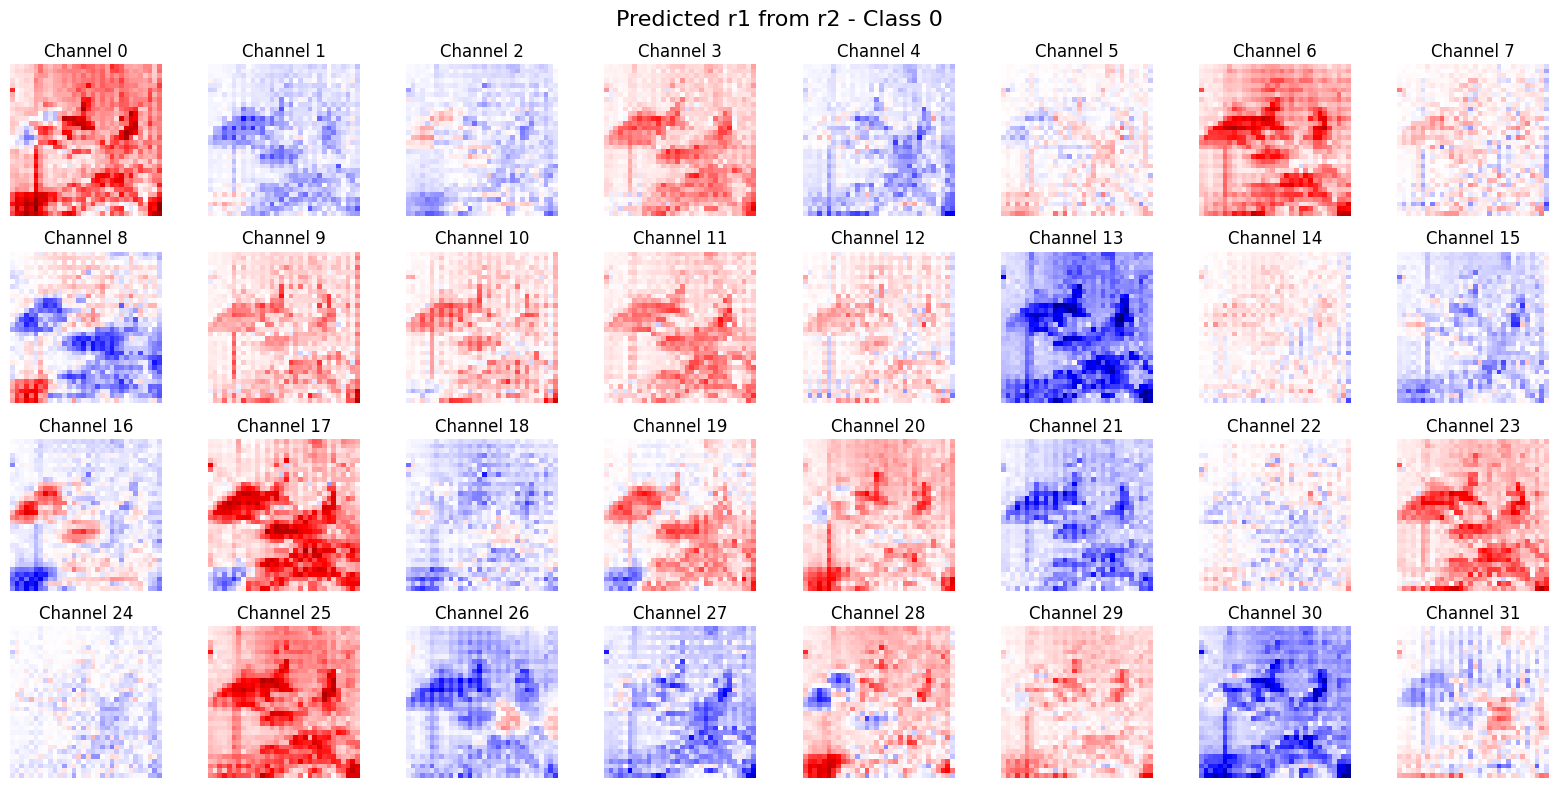

In [13]:
feature = last_predicted_r1.detach().cpu()
max_abs = feature.abs().max().item()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for j, ax in enumerate(axes.flat):
    ax.imshow(feature[j], cmap="seismic", vmin=-max_abs, vmax=max_abs)
    ax.set_title(f"Channel {j}")
    ax.axis("off")

fig.suptitle(f"Predicted r1 from r2 - Class {last_label}", fontsize=16)

plt.tight_layout()
plt.show()

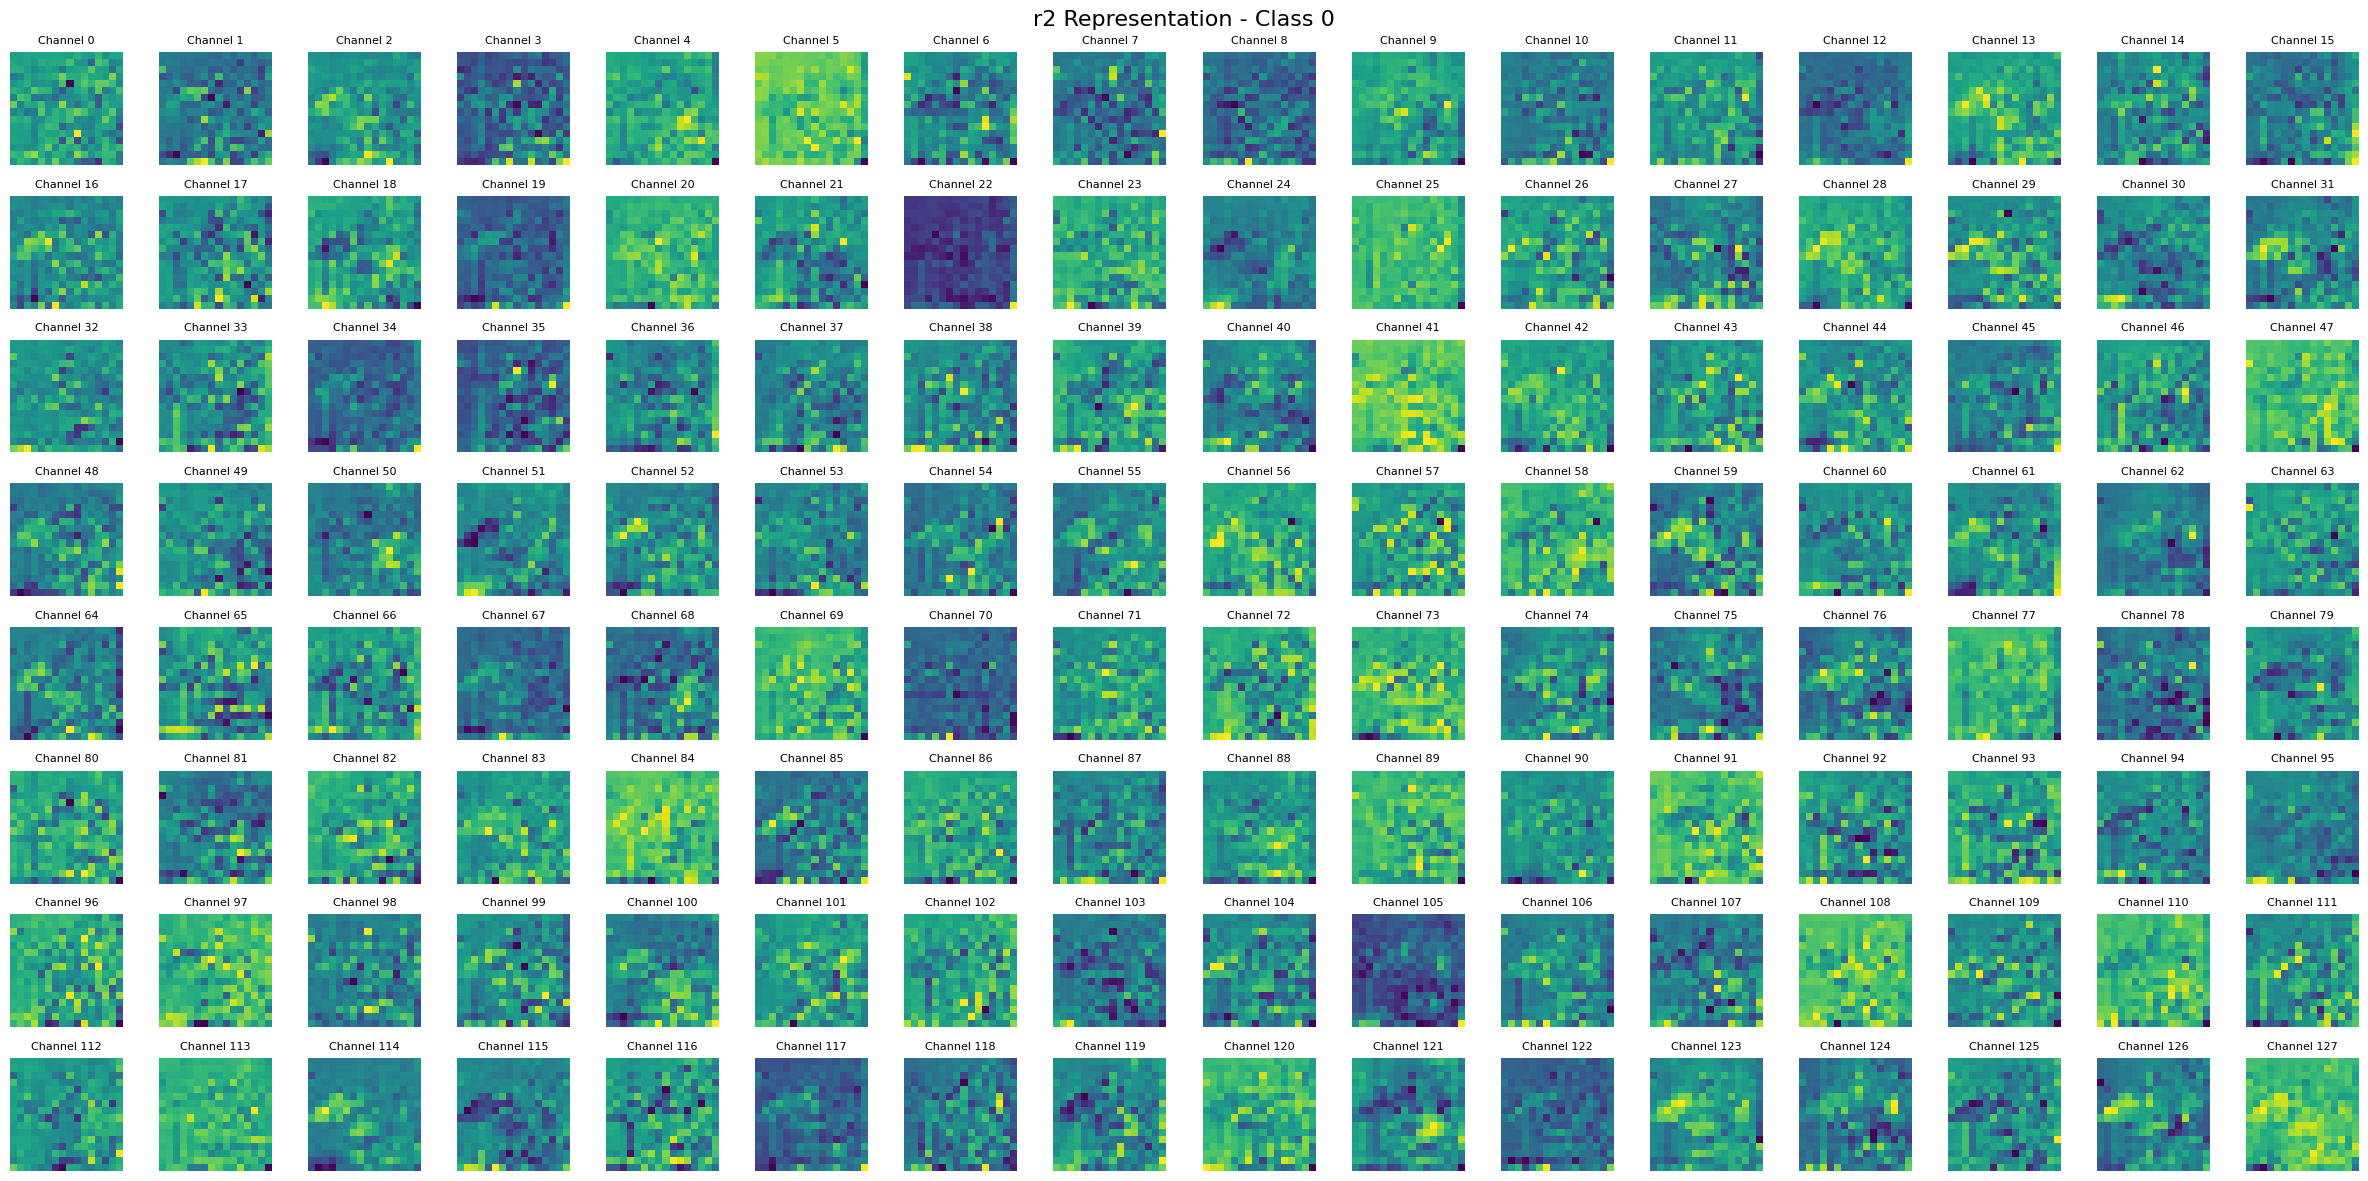

In [14]:
feature = last_r2.detach().cpu()

fig, axes = plt.subplots(8, 16, figsize=(24, 12))

for j, ax in enumerate(axes.flat):
    ax.imshow(feature[j])
    ax.set_title(f"Channel {j}", fontsize=8)
    ax.axis("off")

fig.suptitle(f"r2 Representation - Class {last_label}", fontsize=16)

plt.tight_layout()
plt.show()

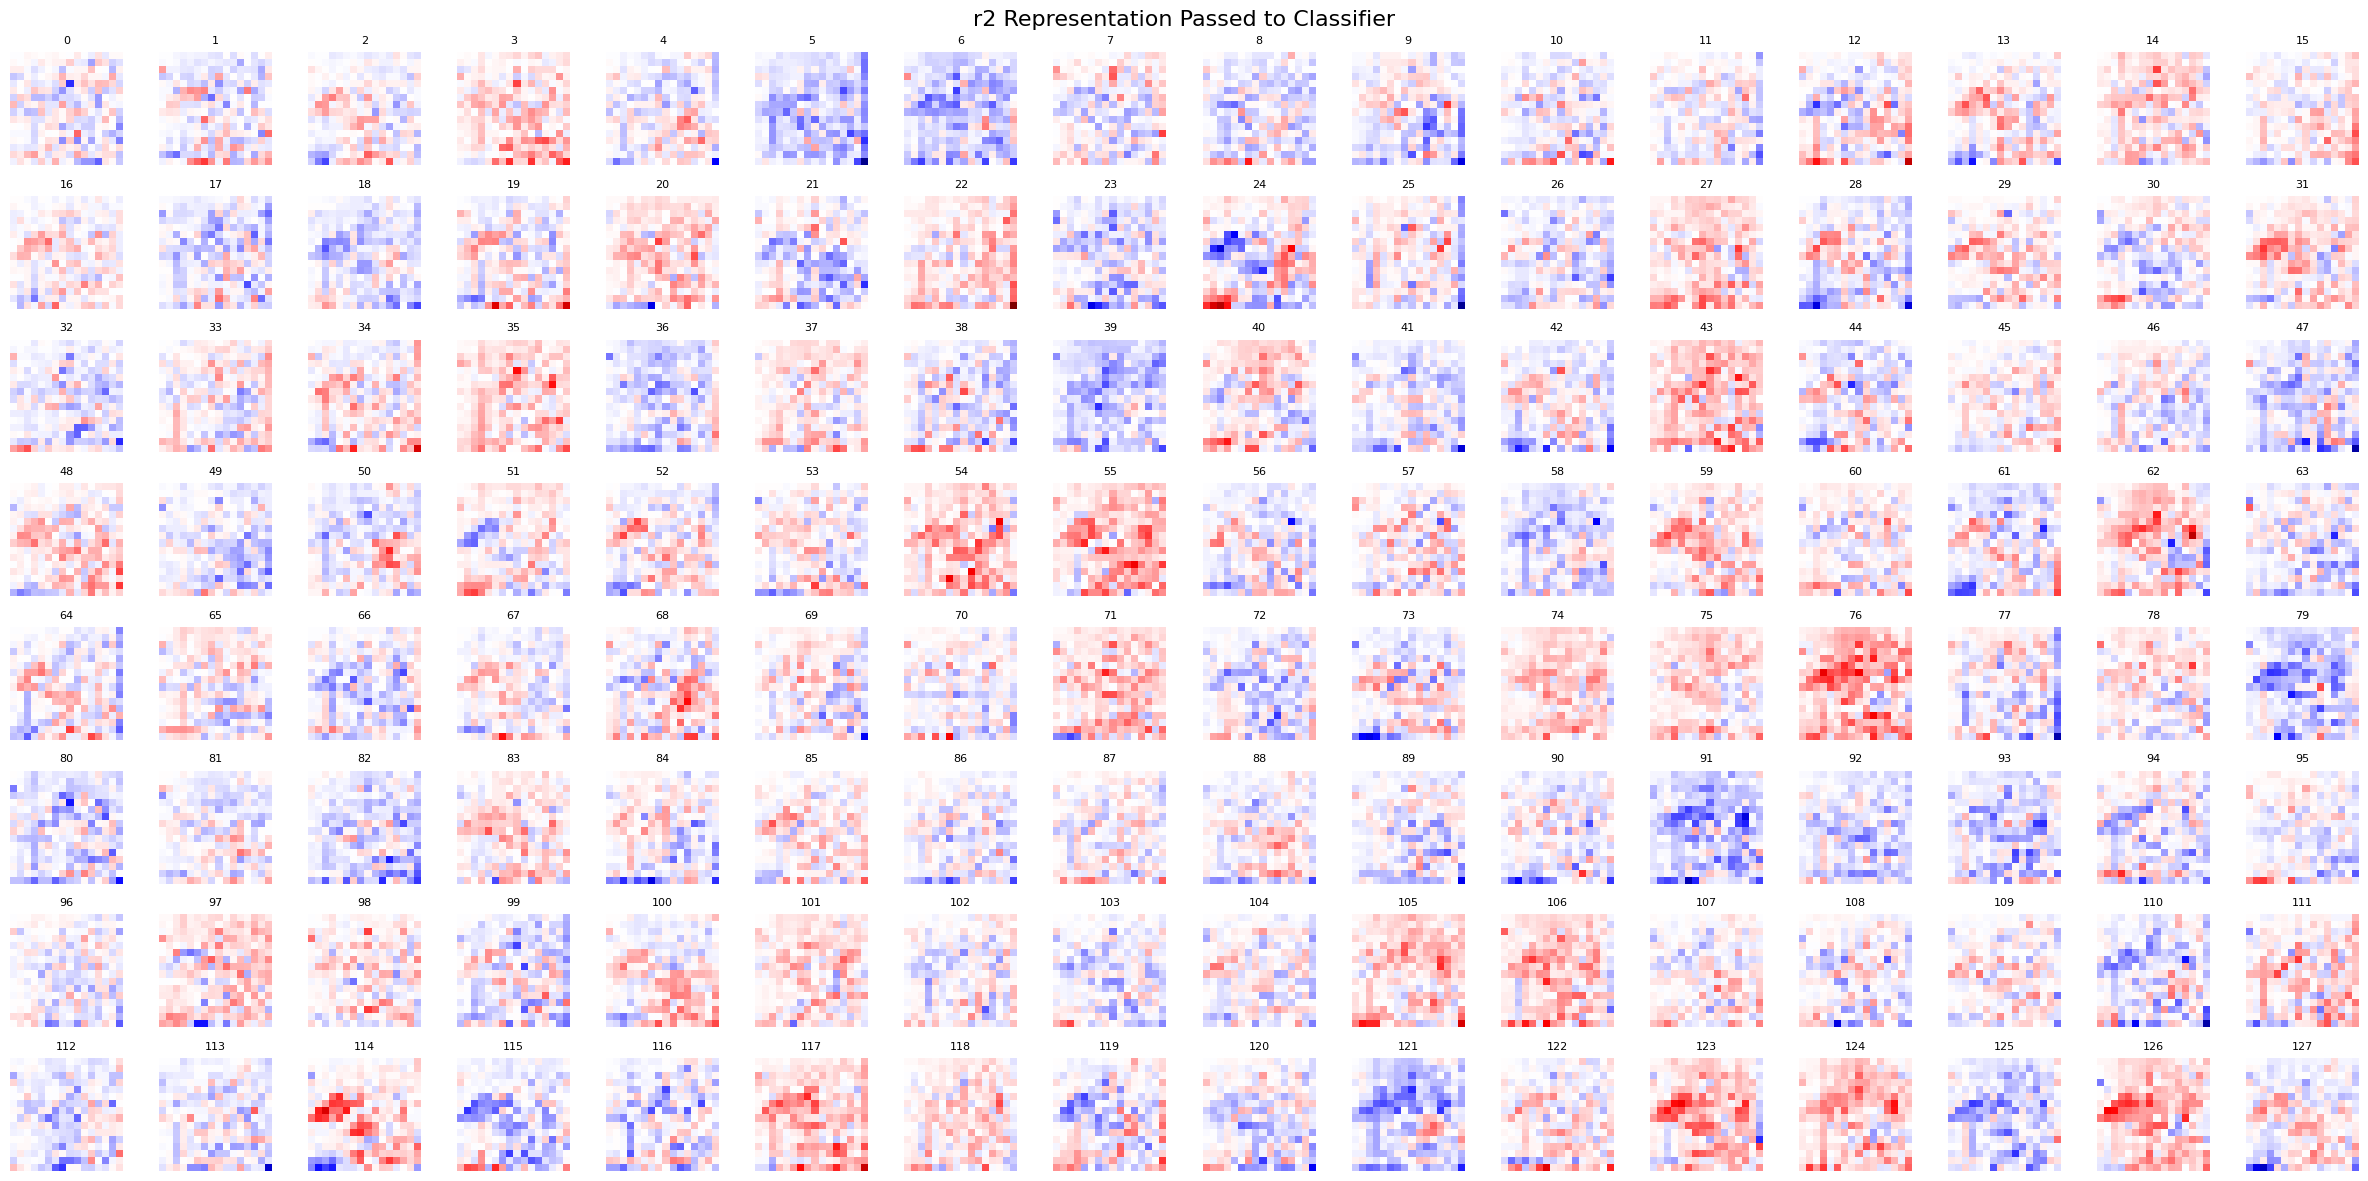

In [15]:
feature = last_r2.detach().cpu()
max_abs = feature.abs().max().item()

fig, axes = plt.subplots(8, 16, figsize=(24, 12))

for j, ax in enumerate(axes.flat):
    ax.imshow(feature[j], cmap="seismic", vmin=-max_abs, vmax=max_abs)
    ax.set_title(f"{j}", fontsize=8)
    ax.axis("off")

fig.suptitle("r2 Representation Passed to Classifier", fontsize=16)

plt.tight_layout()
plt.show()

In [17]:
torch.save(r2.detach().cpu(), "r2_none.pt")

In [ ]:
image, label = train_subset[0]
reconstruction, predicted_r1, reconstruction_r2, r2, steps, converged = model.reconstruct(image)

print("Original")
print("R mean =", image[0].mean().item(), "std =", image[0].std().item())
print("G mean =", image[1].mean().item(), "std =", image[1].std().item())
print("B mean =", image[2].mean().item(), "std =", image[2].std().item())

print("\nReconstruction")
print("R mean =", reconstruction[0].mean().item(), "std =", reconstruction[0].std().item())
print("G mean =", reconstruction[1].mean().item(), "std =", reconstruction[1].std().item())
print("B mean =", reconstruction[2].mean().item(), "std =", reconstruction[2].std().item())

print("\nChannel differences in reconstruction")
print("R-G =", (reconstruction[0] - reconstruction[1]).abs().mean().item())
print("R-B =", (reconstruction[0] - reconstruction[2]).abs().mean().item())
print("G-B =", (reconstruction[1] - reconstruction[2]).abs().mean().item())

print("\nOriginal channel differences")
print("R-G =", (image[0] - image[1]).abs().mean().item())
print("R-B =", (image[0] - image[2]).abs().mean().item())
print("G-B =", (image[1] - image[2]).abs().mean().item())

print("Inference step =", steps)

In [ ]:
test_dataset = cleaned_tiny_imagenet[1]

indices = torch.randperm(len(test_dataset), generator=generator)[:10].tolist()

test_subset = Subset(test_dataset, indices)
test_loader = DataLoader(test_subset, batch_size=5, shuffle=True)

images, labels = next(iter(test_loader))

image, label = images[0], labels[0]
reconstruction, predicted_r1, reconstruction_r2, steps, converged = model.reconstruct(image)
print(reconstruction[0].shape, steps, converged)

In [ ]:
num_images = 5

fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 4))

for i in range(num_images):
    image, label = test_subset[i]

    reconstruction, predicted_r1, reconstruction_r2, r2, steps, converged = model.reconstruct(image)

    axes[i, 0].imshow(to_display_image(image))
    axes[i, 0].set_title(f"Original - Class {label}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(to_display_image(reconstruction))
    axes[i, 1].set_title(f"PC-CNN Reconstruction - {steps} steps - Converged {converged}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image, label = test_subset[0]
reconstruction, predicted_r1, reconstruction_r2, r2, steps, converged = model.reconstruct(image)

print("Original")
print("R mean =", image[0].mean().item(), "std =", image[0].std().item())
print("G mean =", image[1].mean().item(), "std =", image[1].std().item())
print("B mean =", image[2].mean().item(), "std =", image[2].std().item())

print("\nReconstruction")
print("R mean =", reconstruction[0].mean().item(), "std =", reconstruction[0].std().item())
print("G mean =", reconstruction[1].mean().item(), "std =", reconstruction[1].std().item())
print("B mean =", reconstruction[2].mean().item(), "std =", reconstruction[2].std().item())

print("\nChannel differences in reconstruction")
print("R-G =", (reconstruction[0] - reconstruction[1]).abs().mean().item())
print("R-B =", (reconstruction[0] - reconstruction[2]).abs().mean().item())
print("G-B =", (reconstruction[1] - reconstruction[2]).abs().mean().item())

print("\nOriginal channel differences")
print("R-G =", (image[0] - image[1]).abs().mean().item())
print("R-B =", (image[0] - image[2]).abs().mean().item())
print("G-B =", (image[1] - image[2]).abs().mean().item())

print("\nReconstruction channel differences")
print("R-G =", (reconstruction[0] - reconstruction[1]).abs().mean().item())
print("R-B =", (reconstruction[0] - reconstruction[2]).abs().mean().item())
print("G-B =", (reconstruction[1] - reconstruction[2]).abs().mean().item())

print("Inference step =", steps)
print("Converged =", converged)

In [ ]:
image, label = train_dataset[0]

print(image.min().item())
print(image.max().item())
print(image.mean().item())
print(image.dtype)